<h1>Train — InceptionNet v3</h1>

Trains and evaluates InceptionNet v3 using the tuned hyperparameters from `ARCH_HYPERPARAMS["inception_v3"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): NoordelikeWerke
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 1692 | Val: 410 | Test: 405


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["inception_v3"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"InceptionNet v3: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

InceptionNet v3: micro batch = 16, accumulation steps = 2 (effective batch size ≈ 32, tuned value = 32)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with InceptionNet v3)
# ---------------------------------------------------------
model = models.inception_v3(weights=models.Inception_V3_Weights.IMAGENET1K_V1, aux_logits=True)

in_f = model.fc.in_features
model.fc = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

# The auxiliary classifier (used only during training, see run_epoch in
# wwtw_utils.py) also needs its output layer resized to our number of classes.
in_f_aux = model.AuxLogits.fc.in_features
model.AuxLogits.fc = nn.Linear(in_f_aux, num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs, per the Bayesian-optimized step size.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[InceptionNet v3] Using gradient accumulation: 2 micro-batches per optimizer step (effective batch size ≈ micro_batch x 2).


[InceptionNet v3] Epoch   1/100 | LR: 1.00e-04 | train loss 1.5833 acc 0.483 | val loss 0.9270 acc 0.607 *


[InceptionNet v3] Epoch   2/100 | LR: 1.00e-04 | train loss 1.0339 acc 0.662 | val loss 0.5588 acc 0.761 *


[InceptionNet v3] Epoch   3/100 | LR: 1.00e-04 | train loss 0.7503 acc 0.780 | val loss 0.6172 acc 0.739


[InceptionNet v3] Epoch   4/100 | LR: 1.00e-04 | train loss 0.6344 acc 0.812 | val loss 0.4958 acc 0.839 *


...

[InceptionNet v3] Epoch  26/100 | LR: 1.00e-05 | train loss 0.0550 acc 0.982 | val loss 0.4422 acc 0.905


[InceptionNet v3] Epoch  27/100 | LR: 1.00e-05 | train loss 0.0509 acc 0.989 | val loss 0.4036 acc 0.905


[InceptionNet v3] Epoch  28/100 | LR: 1.00e-05 | train loss 0.0539 acc 0.983 | val loss 0.4279 acc 0.905


[InceptionNet v3] Epoch  29/100 | LR: 1.00e-05 | train loss 0.0478 acc 0.986 | val loss 0.4475 acc 0.898


[InceptionNet v3] Epoch  30/100 | LR: 1.00e-06 | train loss 0.0442 acc 0.988 | val loss 0.4537 acc 0.895

[InceptionNet v3] No val loss improvement for 10 epochs — stopping early at epoch 30.

[InceptionNet v3] Restored best checkpoint (val loss = 0.3674)


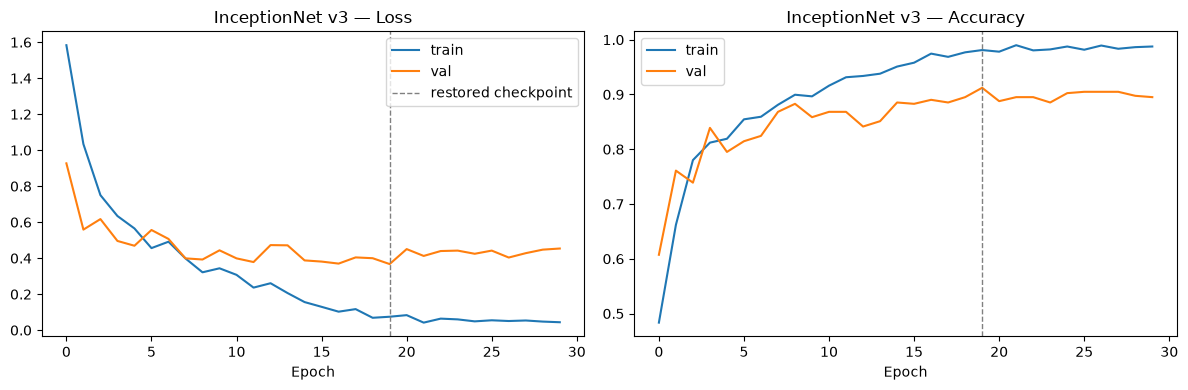

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "InceptionNet v3", is_inception=True,
    accum_steps=accum_steps,
)
plot_training_curves(history, "InceptionNet v3")

## Evaluate on the test set

[InceptionNet v3] Test accuracy: 0.763


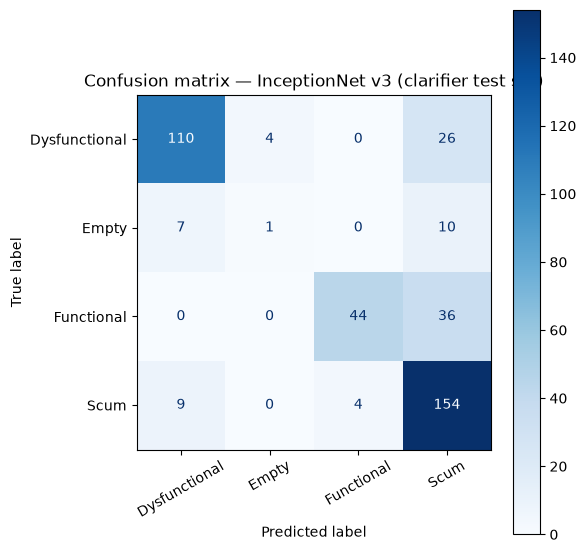

               precision    recall  f1-score   support

Dysfunctional      0.873     0.786     0.827       140
        Empty      0.200     0.056     0.087        18
   Functional      0.917     0.550     0.688        80
         Scum      0.681     0.922     0.784       167

     accuracy                          0.763       405
    macro avg      0.668     0.578     0.596       405
 weighted avg      0.773     0.763     0.749       405



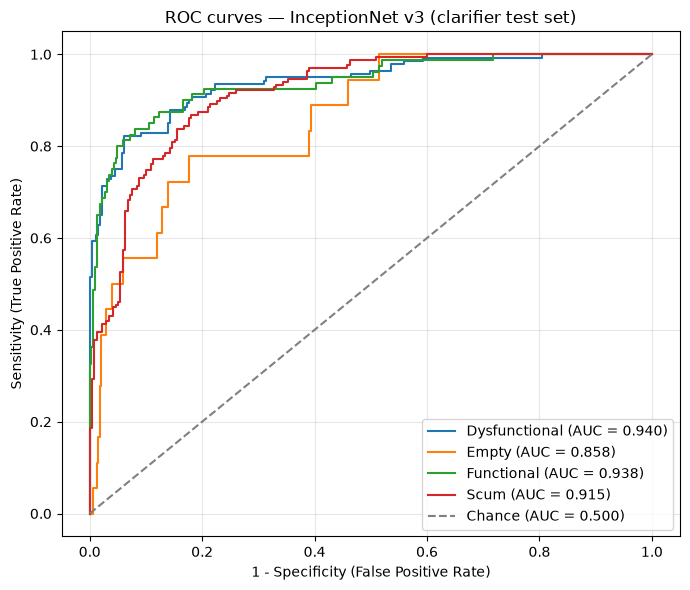

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.940
  Empty          : 0.858
  Functional     : 0.938
  Scum           : 0.915

Mean AUC (over 4/4 classes with test examples): 0.913


(np.float64(0.762962962962963),
 {'Dysfunctional': 0.939946091644205,
  'Empty': 0.8578811369509044,
  'Functional': 0.9376923076923077,
  'Scum': 0.9152367533839884})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "InceptionNet v3", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("InceptionNet v3", "inception_v3")

Saved results to ../results/results_clarifier_inception_v3_NoordelikeWerke.pkl
Saved model weights to ../models/clarifier_inception_v3_cnn.pt
